<a href="https://colab.research.google.com/github/Ayushman125/Essentials_of_AI/blob/main/EAI_Lab_4(a).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiment 4(a): Analysis of proximity  measures for various ATTRIBUTE types

##Write a python script for:


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

# CUSTOM CORE MATHEMATICAL FUNCTIONS

def square_root(x):
    """Calculates square root"""
    if x <= 0:
        return 0.0
    guess = x / 2.0
    for _ in range(20):
        guess = (guess + x / guess) / 2.0
    return guess

def absolute(x):
    """Calculates absolute value."""
    return x if x >= 0 else -x


def print_matrix(matrix, title="Dissimilarity Matrix [D] n x n"):
    """Prints formatted matrix to terminal using Pandas."""
    n = len(matrix)
    labels = [f"Obj_{i}" for i in range(n)]

    # Convert raw 2D list to a Pandas DataFrame for clean printing
    df = pd.DataFrame(matrix, index=labels, columns=labels)

    print(f"\n--- {title} ---")
    print(df.round(3))  # Formats float values to 3 decimal places


def plot_heatmap_text(matrix, title="Matrix Visual Plotter", vmin=None, vmax=None):
    """Visualizes matrix graphically with custom range scaling."""
    n = len(matrix)
    labels = [f"Obj_{i}" for i in range(n)]

    df = pd.DataFrame(matrix, index=labels, columns=labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        df,
        annot=True,
        cmap="YlOrRd",
        fmt=".3f",
        cbar=True,
        vmin=vmin,  # e.g., set vmin=0.0 to see true similarity scale
        vmax=vmax   # e.g., set vmax=1.0
    )

    plt.title(title)
    plt.xlabel("Objects")
    plt.ylabel("Objects")
    plt.tight_layout()
    plt.show()

###a) NOMINAL DISSIMILARITY MATRIX
 Formula: d(i,j) = (p - m) / p

In [ ]:
def nominal_dissimilarity(data):
    n = len(data)
    p = len(data[0])  # Total number of attributes
    D = [[0.0] * n for _ in range(n)]

    for i in range(n):
        for j in range(n):
            if i == j:
                D[i][j] = 0.0
            else:
                m = sum(1 for k in range(p) if data[i][k] == data[j][k])  # Matches
                D[i][j] = (p - m) / p
    return D


#### b) BINARY DISSIMILARITY MATRIX (SYMMETRIC & ASYMMETRIC)
#### Contingency Table:
#### q = (1,1), r = (1,0), s = (0,1), t = (0,0)

In [ ]:
def binary_dissimilarity(data, symmetric=True):
    n = len(data)
    num_features = len(data[0]) if n > 0 else 0
    D = [[0.0] * n for _ in range(n)]

    if num_features == 0:
        return D

    for i in range(n):
        for j in range(i + 1, n):  # Compute upper triangle only (since D[i][j] == D[j][i])
            q = r = s = t = 0

            # Single-pass accumulation for (q, r, s, t)
            for k in range(num_features):
                val_i, val_j = data[i][k], data[j][k]
                if val_i == 1 and val_j == 1:
                    q += 1
                elif val_i == 1 and val_j == 0:
                    r += 1
                elif val_i == 0 and val_j == 1:
                    s += 1
                else:
                    t += 1

            if symmetric:
                denom = q + r + s + t
                dist = (r + s) / denom if denom != 0 else 0.0
            else:
                denom = q + r + s
                dist = (r + s) / denom if denom != 0 else 0.0

            # Assign symmetrically across the diagonal
            D[i][j] = dist
            D[j][i] = dist

    return D

#### c) NUMERICAL DISSIMILARITY (EUCLIDEAN & MANHATTAN)

In [ ]:
def numerical_dissimilarity(data, metric='euclidean'):
    n = len(data)
    p = len(data[0])
    D = [[0.0] * n for _ in range(n)]

    for i in range(n):
        for j in range(n):
            if metric == 'euclidean':
                # Formula: sqrt( sum( (x_ik - x_jk)^2 ) )
                sq_sum = sum((data[i][k] - data[j][k]) ** 2 for k in range(p))
                D[i][j] = square_root(sq_sum)
            elif metric == 'manhattan':
                # Formula: sum( |x_ik - x_jk| )
                D[i][j] = sum(absolute(data[i][k] - data[j][k]) for k in range(p))
    return D

#### d) ORDINAL DISSIMILARITY MATRIX
#### Converts mapped ranks to range [0, 1] using z_if = (r_if - 1) / (M_f - 1)

In [ ]:
def ordinal_dissimilarity(data, max_ranks):
    n = len(data)
    p = len(data[0])

    # Map attributes to [0, 1] range
    z_data = []
    for i in range(n):
        z_row = []
        for f in range(p):
            r_if = data[i][f]
            M_f = max_ranks[f]
            z_if = (r_if - 1) / (M_f - 1)
            z_row.append(z_if)
        z_data.append(z_row)

    # Calculate Euclidean distance on normalized ranks
    return numerical_dissimilarity(z_data, metric='euclidean')

#### e) COSINE SIMILARITY MEASURE ANALYSIS
#### Formula: Sim(A, B) = (A . B) / (||A|| * ||B||)

In [ ]:
def cosine_similarity(data):
    n = len(data)
    p = len(data[0])
    S = [[0.0] * n for _ in range(n)]

    for i in range(n):
        for j in range(n):
            dot_product = sum(data[i][k] * data[j][k] for k in range(p))
            norm_a = square_root(sum(data[i][k] ** 2 for k in range(p)))
            norm_b = square_root(sum(data[j][k] ** 2 for k in range(p)))

            if norm_a != 0 and norm_b != 0:
                S[i][j] = dot_product / (norm_a * norm_b)
            else:
                S[i][j] = 0.0
    return S

#### EXECUTION CODE


 CALCULATING DISSIMILARITY MATRICES 

--- a) Nominal Dissimilarity Matrix ---
       Obj_0  Obj_1  Obj_2  Obj_3
Obj_0    0.0    1.0    0.5    0.5
Obj_1    1.0    0.0    0.5    1.0
Obj_2    0.5    0.5    0.0    1.0
Obj_3    0.5    1.0    1.0    0.0

--- b) Symmetric Binary Dissimilarity Matrix ---
       Obj_0  Obj_1  Obj_2  Obj_3
Obj_0   0.00   0.50   0.50   0.75
Obj_1   0.50   0.00   0.50   0.75
Obj_2   0.50   0.50   0.00   0.75
Obj_3   0.75   0.75   0.75   0.00

--- b) Asymmetric Binary Dissimilarity Matrix ---
       Obj_0  Obj_1  Obj_2  Obj_3
Obj_0  0.000  0.667  0.667    1.0
Obj_1  0.667  0.000  0.667    1.0
Obj_2  0.667  0.667  0.000    1.0
Obj_3  1.000  1.000  1.000    0.0

--- c) Numerical - Euclidean Distance Matrix ---
       Obj_0  Obj_1  Obj_2  Obj_3
Obj_0  0.000  1.414  7.211  9.899
Obj_1  1.414  0.000  5.831  8.485
Obj_2  7.211  5.831  0.000  3.162
Obj_3  9.899  8.485  3.162  0.000

--- c) Numerical - Manhattan Distance Matrix ---
       Obj_0  Obj_1  Obj_2  Obj_3
Obj_0 

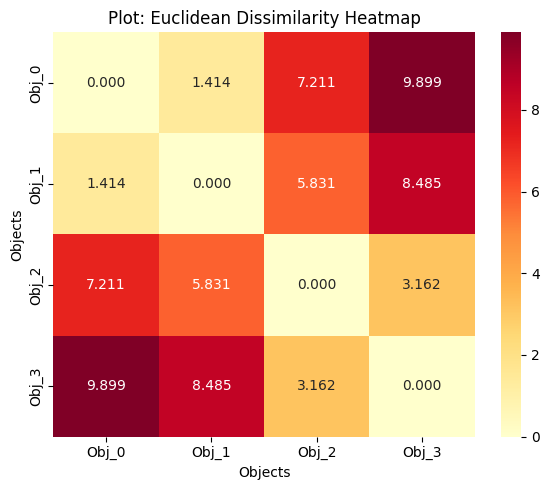

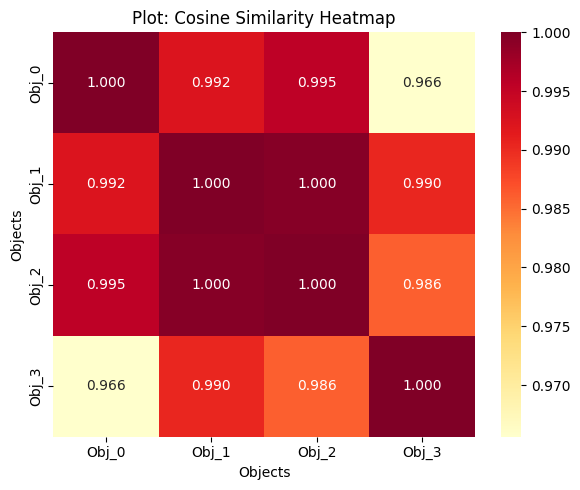

In [ ]:
if __name__ == "__main__":

    # 1. Nominal Data (e.g., Color, Map Shape)
    data_nominal = [
        ["Red", "Circle"],
        ["Blue", "Square"],
        ["Red", "Square"],
        ["Green", "Circle"]
    ]

    # 2. Binary Data (0 or 1 attributes, e.g., Symptoms present)
    data_binary = [
        [1, 1, 0, 0],
        [1, 0, 1, 0],
        [0, 1, 1, 0],
        [0, 0, 0, 1]
    ]

    # 3. Numerical Data (e.g., Age, Income)
    data_numerical = [
        [1.0, 2.0],
        [2.0, 3.0],
        [5.0, 8.0],
        [8.0, 9.0]
    ]

    # 4. Ordinal Data (e.g., Satisfaction levels rated 1 to 5)
    data_ordinal = [
        [1, 3],  # Poor, Medium
        [2, 4],  # Fair, Good
        [5, 5],  # Excellent, Excellent
        [1, 1]   # Poor, Poor
    ]
    max_ranks = [5, 5]  # Max level per rank feature

    # --- Calculations ---
    print("\n" + "="*60)
    print(" CALCULATING DISSIMILARITY MATRICES ")
    print("="*60)

    # a) Nominal
    D_nominal = nominal_dissimilarity(data_nominal)
    print_matrix(D_nominal, "a) Nominal Dissimilarity Matrix")

    # b) Binary (Symmetric & Asymmetric)
    D_bin_sym = binary_dissimilarity(data_binary, symmetric=True)
    print_matrix(D_bin_sym, "b) Symmetric Binary Dissimilarity Matrix")

    D_bin_asym = binary_dissimilarity(data_binary, symmetric=False)
    print_matrix(D_bin_asym, "b) Asymmetric Binary Dissimilarity Matrix")

    # c) Numerical (Euclidean & Manhattan)
    D_euclidean = numerical_dissimilarity(data_numerical, metric='euclidean')
    print_matrix(D_euclidean, "c) Numerical - Euclidean Distance Matrix")

    D_manhattan = numerical_dissimilarity(data_numerical, metric='manhattan')
    print_matrix(D_manhattan, "c) Numerical - Manhattan Distance Matrix")

    # d) Ordinal
    D_ordinal = ordinal_dissimilarity(data_ordinal, max_ranks)
    print_matrix(D_ordinal, "d) Ordinal Dissimilarity Matrix")

    # e) Cosine Similarity
    S_cosine = cosine_similarity(data_numerical)
    print_matrix(S_cosine, "e) Cosine Similarity Matrix Analysis")

    # --- Matrix Plotting ---
    plot_heatmap_text(D_euclidean, "Plot: Euclidean Dissimilarity Heatmap")
    plot_heatmap_text(S_cosine, "Plot: Cosine Similarity Heatmap")